# Import necessary libraries

In [ ]:
%pip install openpyxl

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

# Import Database

In [2]:
database = 'Cytotoxicity_Dataset_C2 updated'

# Create DataFrames for each type of properties

In [3]:
# Physicochemical properties DataFrame
df_physicochem = pd.read_excel(f'{database}.xlsx', sheet_name='Polymer_info')

# Experimental conditions DataFrame
df_experimental = pd.read_excel(f'{database}.xlsx', sheet_name='Cytotoxicity_Experimental_Param')

# Ecotoxicity outputs DataFrame
df_cytotox = pd.read_excel(f'{database}.xlsx', sheet_name='Cytotoxicity_Outputs')

In [4]:
# Create final DataFrame
df_final = pd.concat(
    [df_physicochem,
     df_experimental.drop(columns=['Study_id','Instance']),
     df_cytotox.drop(columns=['Study_id','Instance'])],
    axis=1
)

In [5]:
# --- 1) Clean column names (also remove * and ()) ---
def tidy_colnames(cols: pd.Index) -> pd.Index:
    out = (cols.astype(str)
           .str.strip()                               # trim ends
           .str.lower()                               # lowercase
           .str.replace(r'[*()]', '', regex=True)     # REMOVE *, (
           .str.replace(r'\s+', '_', regex=True)      # spaces -> _
           .str.replace(r'[^\w]+', '_', regex=True)   # other non-word -> _
           .str.replace(r'_+', '_', regex=True)       # collapse __
           .str.strip('_'))                           # trim _
    # ensure uniqueness if collisions happen after cleaning
    seen = {}
    uniq = []
    for c in out:
        if c not in seen:
            seen[c] = 0
            uniq.append(c)
        else:
            seen[c] += 1
            uniq.append(f"{c}__{seen[c]}")
    return pd.Index(uniq)

df_final.columns = tidy_colnames(df_final.columns)

# --- 2) Clean categorical/text columns (also remove * and ()) ---
def _clean_text(s: pd.Series) -> pd.Series:
    return (s.astype("string")
              .str.strip()
              .str.lower()
              .str.replace(r'[*()]', '', regex=True)   # remove *, ()
              .str.replace(r'\s+', '_', regex=True)    # spaces -> _
              .str.replace(r'_+', '_', regex=True)     # collapse __
              .str.strip('_'))

# object/string columns
for c in df_final.select_dtypes(include=['object', 'string']).columns:
    df_final[c] = _clean_text(df_final[c])

# category dtype columns (rename categories directly)
for c in df_final.select_dtypes(include=['category']).columns:
    df_final[c] = df_final[c].cat.rename_categories(
        lambda x: (_clean_text(pd.Series([x]))[0] if isinstance(x, str) else x)
    )

In [6]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 436 entries, 0 to 435
Data columns (total 76 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   study_id                             436 non-null    int64  
 1   instance                             436 non-null    int64  
 2   monomer_a                            436 non-null    string 
 3   monomer_b                            216 non-null    string 
 4   hb_ratio                             418 non-null    float64
 5   hv_ratio                             198 non-null    float64
 6   mw                                   194 non-null    float64
 7   mw_units                             185 non-null    string 
 8   mn                                   97 non-null     float64
 9   mn_units                             85 non-null     string 
 10  pdi                                  171 non-null    float64
 11  shape                                420 no

In [7]:
# Process Mw, Mn and PDI columns
# PDI = Mw / Mn

mask_Mw = (
    df_final['mw'].isna() &
    df_final['mn'].notna() &
    df_final['pdi'].notna()
)

mask_Mn = (
    df_final['mn'].isna() &
    df_final['mw'].notna() &
    df_final['pdi'].notna()
)

mask_PDI = (
    df_final['pdi'].isna() &
    df_final['mw'].notna() &
    df_final['mn'].notna()
)

df_final.loc[mask_Mw, 'mw'] = (
    df_final.loc[mask_Mw, 'pdi'] * df_final.loc[mask_Mw, 'mn']
)

df_final.loc[mask_Mn, 'mn'] = (
    df_final.loc[mask_Mn, 'mw'] / df_final.loc[mask_Mn, 'pdi']
)

df_final.loc[mask_PDI, 'pdi'] = (
    df_final.loc[mask_PDI, 'mw'] / df_final.loc[mask_PDI, 'mn']
)


In [8]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 436 entries, 0 to 435
Data columns (total 76 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   study_id                             436 non-null    int64  
 1   instance                             436 non-null    int64  
 2   monomer_a                            436 non-null    string 
 3   monomer_b                            216 non-null    string 
 4   hb_ratio                             418 non-null    float64
 5   hv_ratio                             198 non-null    float64
 6   mw                                   194 non-null    float64
 7   mw_units                             185 non-null    string 
 8   mn                                   205 non-null    float64
 9   mn_units                             85 non-null     string 
 10  pdi                                  184 non-null    float64
 11  shape                                420 no

In [9]:
# Categorical columns to fill with 'not_applicable'
categorical_cols = ['additive1_use', 'additive2_use', 'additive3_use']

# Numerical columns to fill with 0
numeric_cols = ['additive1_percentage', 'additive2_percentage', 'additive3_percentage']

# Fill categorical columns
for col in categorical_cols:
    if col in df_final.columns:
        df_final[col] = df_final[col].fillna('not_applicable').astype(str)

# Fill numerical columns (coerce to numeric, then fill 0)
for col in numeric_cols:
    if col in df_final.columns:
        df_final[col] = pd.to_numeric(df_final[col], errors='coerce').fillna(0)


In [10]:
# Fill 'hv_ratio' with 0
df_final.loc[df_final['hb_ratio'] == 100, 'hv_ratio'] = 0

In [11]:
df_final['concentration_units'].unique()

<StringArray>
[<NA>, 'cm^2/ml', 'μm', 'μg/ml', 'mg/l', 'mg/ml']
Length: 6, dtype: string

In [12]:
# Make 'cm^2/mL' units nan
df_final.loc[df_final['concentration_units'] == 'cm^2/ml', 'concentration_units'] = np.nan
df_final.loc[df_final['concentration_units'] == 'cm^2/ml', 'concentration'] = np.nan

In [13]:
# Unit conversion μΜ to mg/L
df_final.loc[df_final['concentration_units'] == 'μm', 'concentration'] = df_final['concentration'] * df_final['mw'] * 1/1000
df_final.loc[df_final['concentration_units'] == 'μm', 'concentration_units'] = 'mg/l'

In [14]:
# Unit conversion μg/mL to mg/L
df_final.loc[df_final['concentration_units'] == 'μg/ml', 'concentration_units'] = 'mg/l'

In [15]:
# Unit conversion mg/mL to mg/L
df_final.loc[df_final['concentration_units'] == 'mg/ml', 'concentration'] = df_final['concentration'] * 1000
df_final.loc[df_final['concentration_units'] == 'mg/ml', 'concentration_units'] = 'mg/l'

In [16]:
# Check the conversions
df_final['concentration_units'].unique()

<StringArray>
[<NA>, 'mg/l']
Length: 2, dtype: string

In [17]:
df_final.columns

Index(['study_id', 'instance', 'monomer_a', 'monomer_b', 'hb_ratio',
       'hv_ratio', 'mw', 'mw_units', 'mn', 'mn_units', 'pdi', 'shape',
       'shape_grouped', 'thickness', 'units_thickness', 'surface',
       'surface_units', 'diameter', 'diameter_units', 'length', 'length_units',
       'additive', 'additive1_name', 'additive1_percentage',
       'additive1_percentage_units', 'additive1_use', 'additive2_name',
       'additive2_percentage', 'additive2_percentage_units', 'additive2_use',
       'additive3_name', 'additive3_percentage', 'additive3_percentage_units',
       'additive3_use', 'polymer_percentage', 'iso', 'astm', 'assay',
       'assay_grouped', 'cell_line', 'cell_line_grouped', 'cell_line_type',
       'exposure_type', 'no_cells_per_well', 'inoculum_concentration_units',
       'culture_medium', 'culture_medium_grouped', 'dilution_medium',
       'dilution_medium_grouped', 'concentration', 'concentration_units',
       'dilution', 'sterilization_method', 'incubation_t

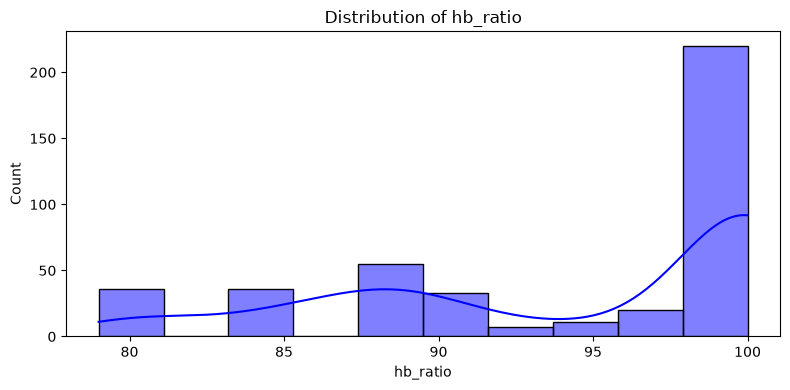

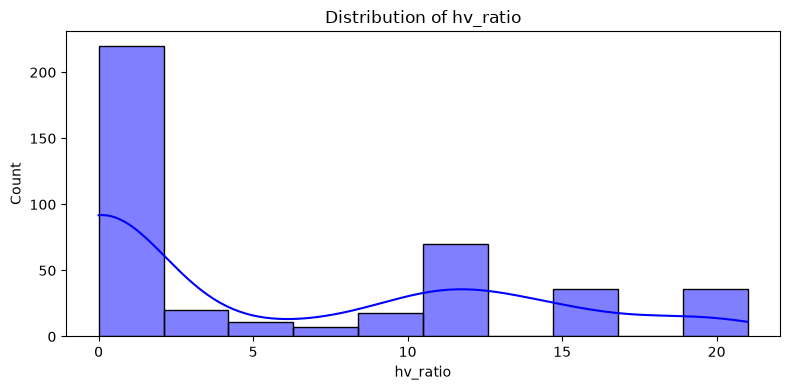

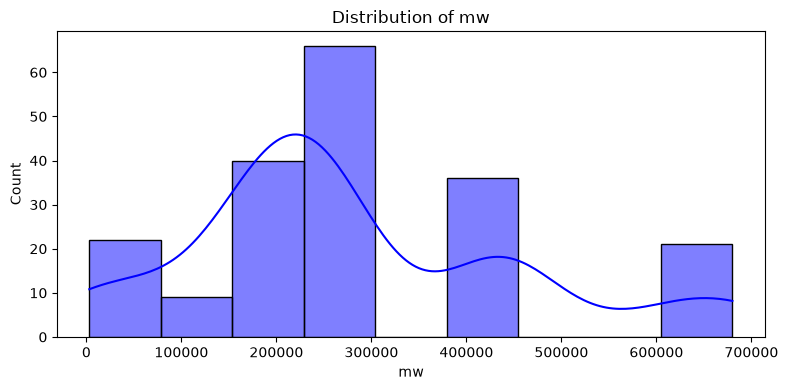

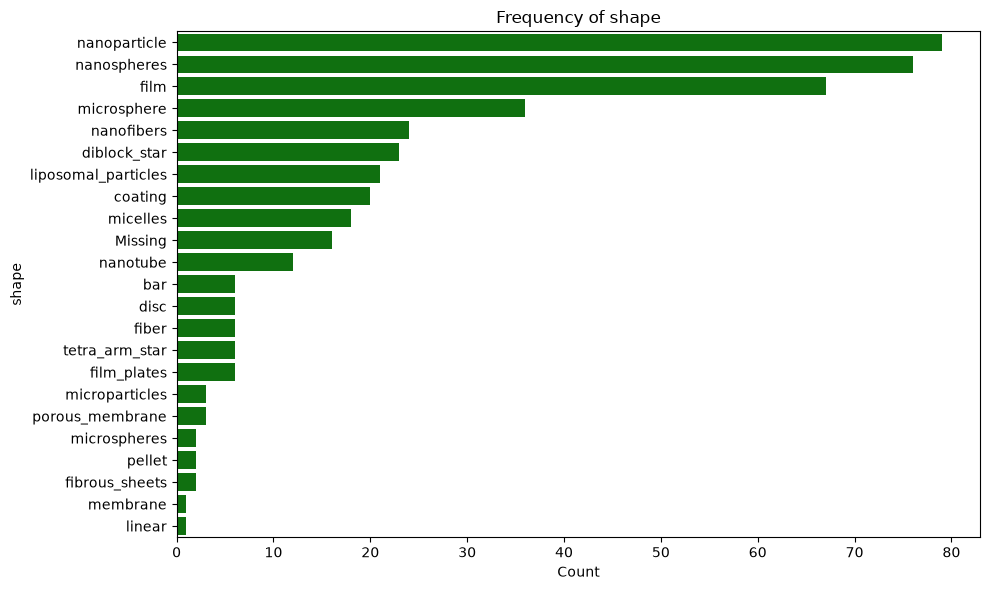

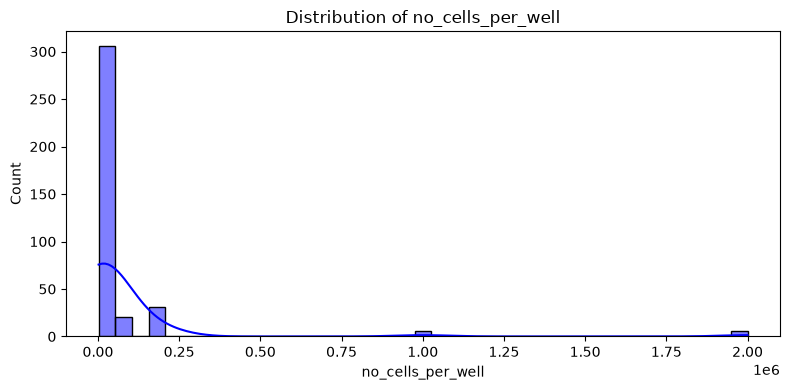

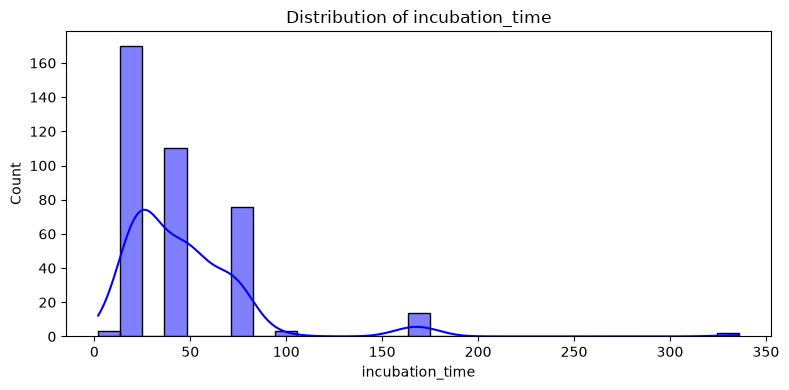

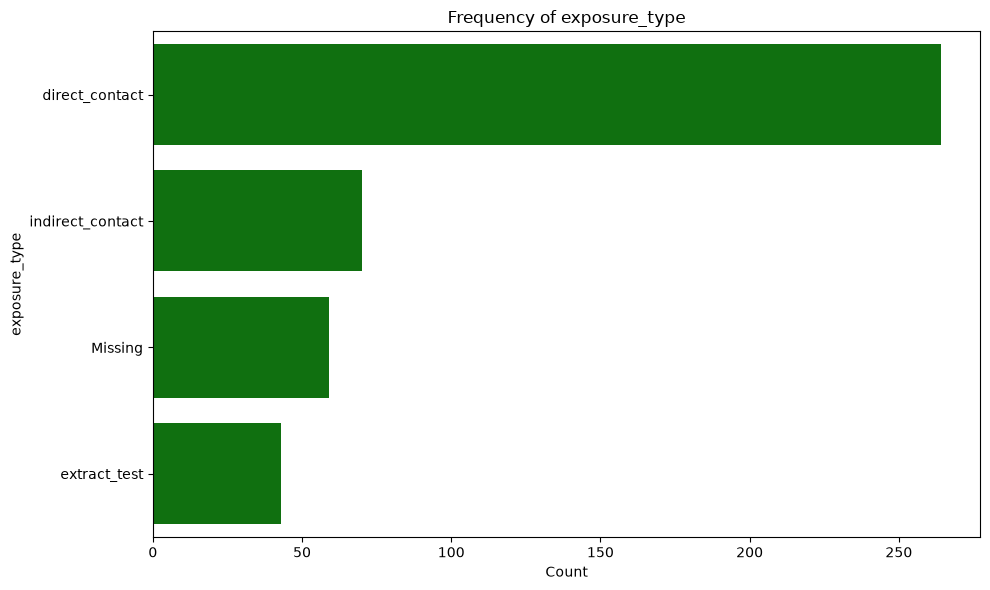

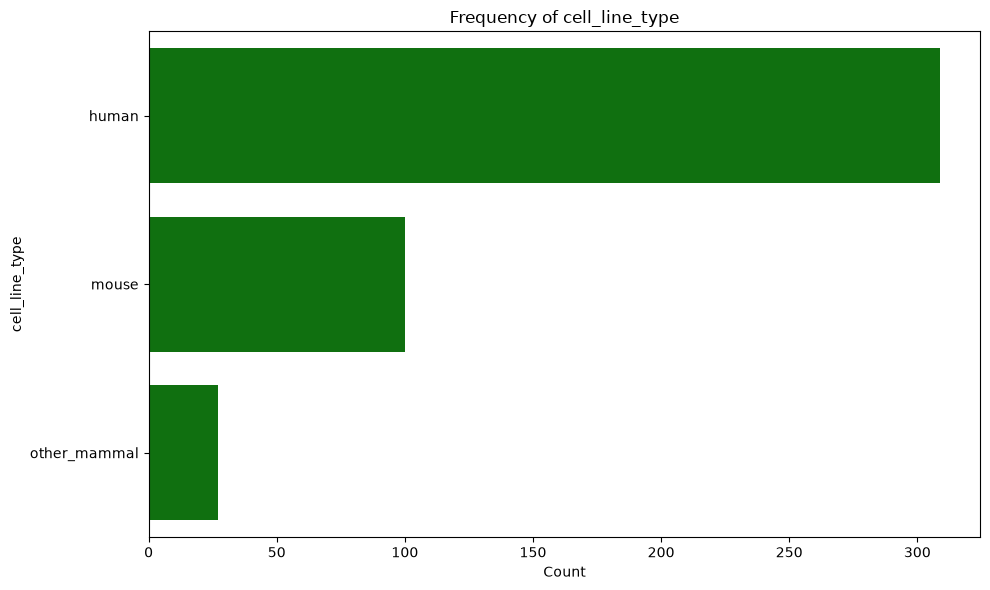

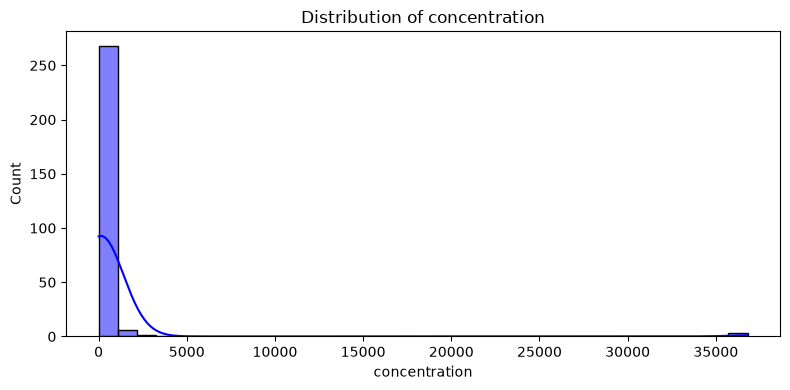

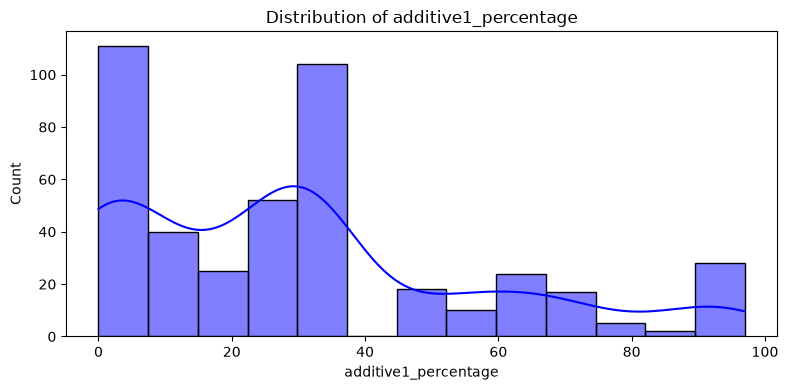

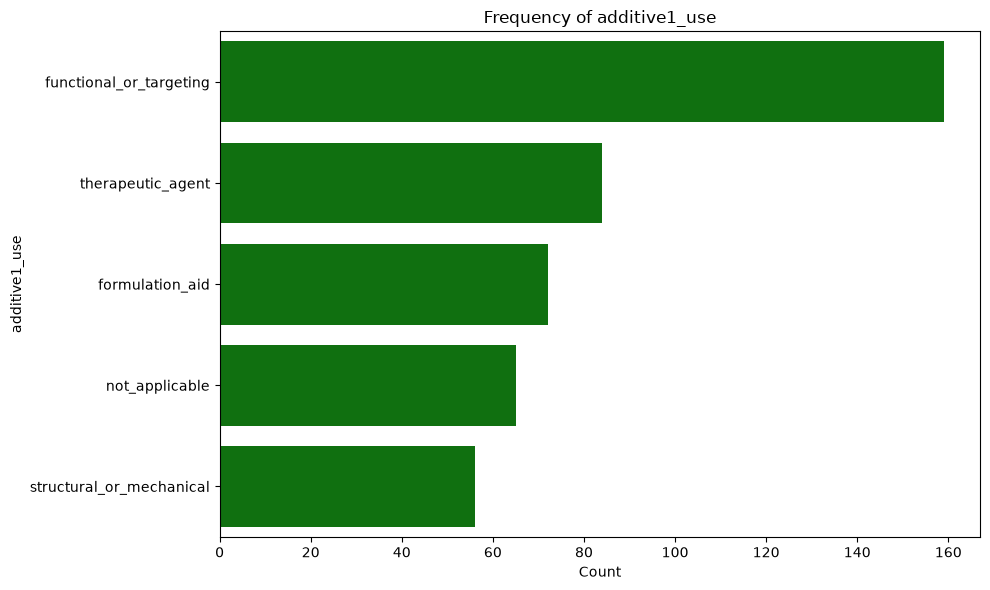

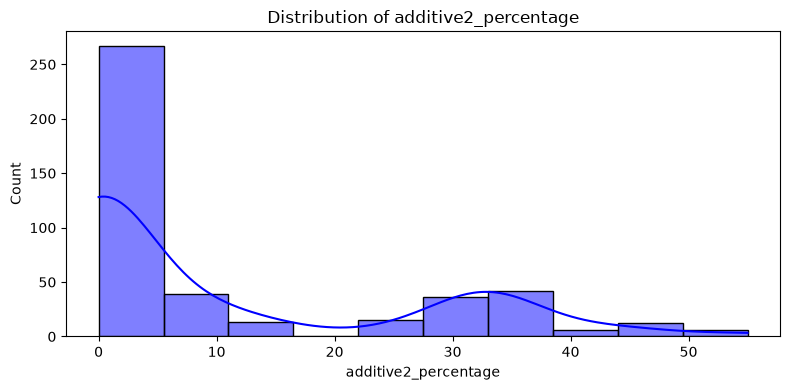

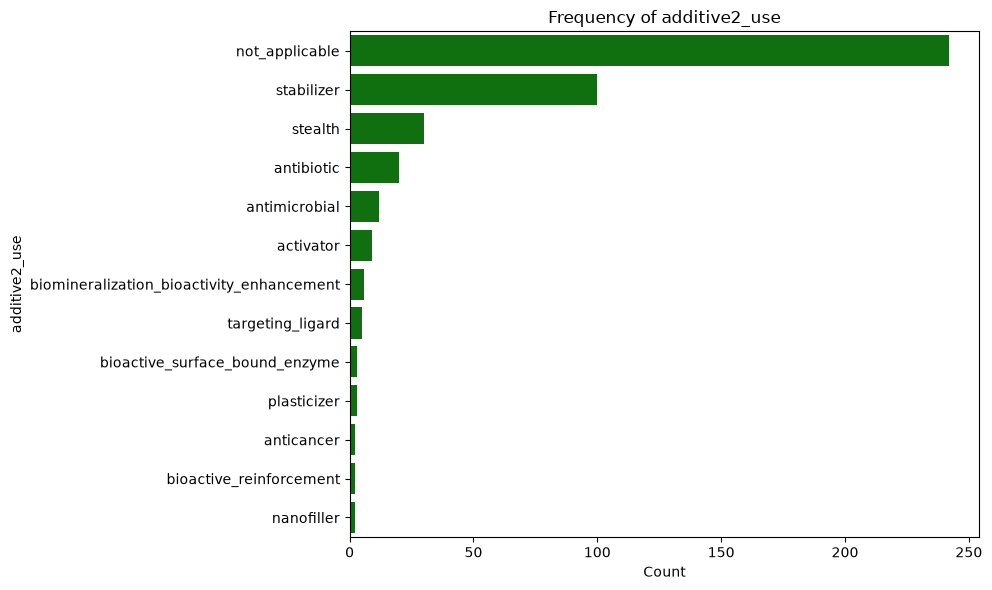

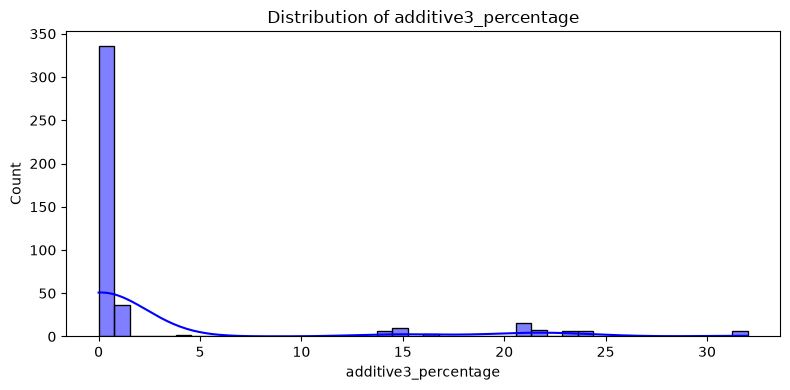

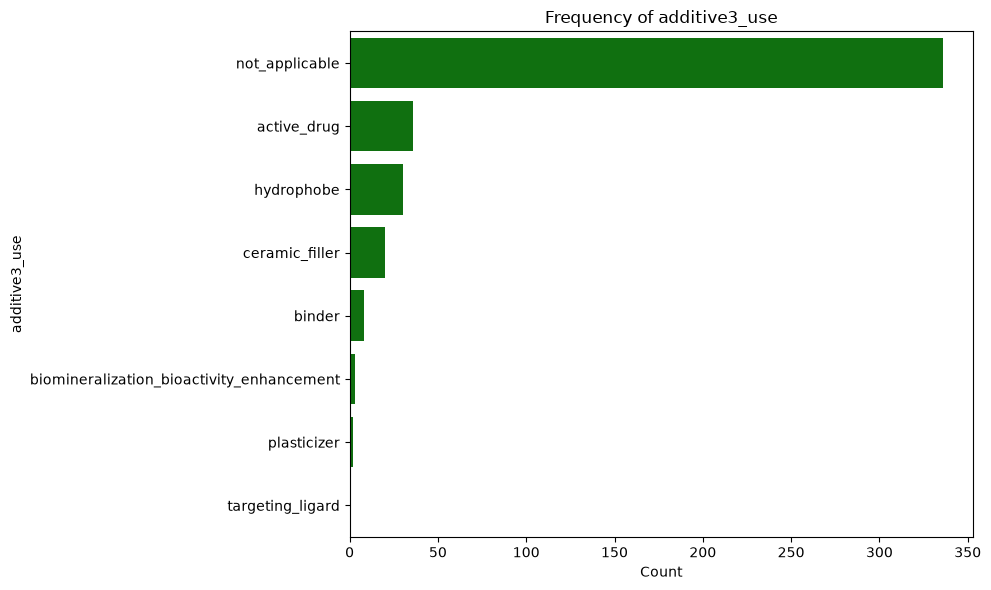

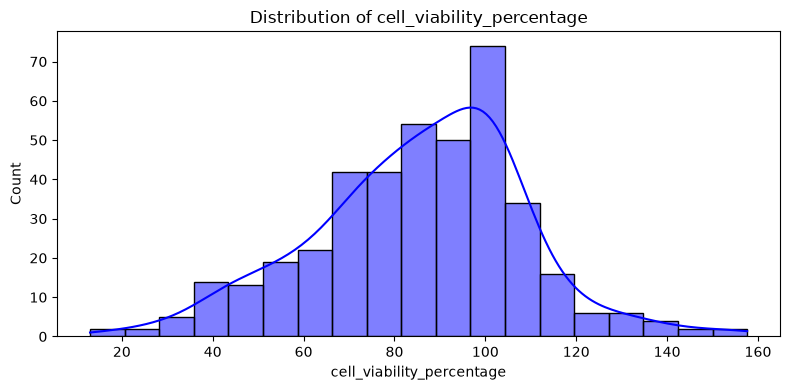

In [19]:
diagran_cols = [
    'hb_ratio',
    'hv_ratio',
    'mw',
    'shape',
    'no_cells_per_well',
    'incubation_time',
    'exposure_type',
    'cell_line_type',
    'concentration',
    'additive1_percentage', 'additive1_use',
    'additive2_percentage', 'additive2_use',
    'additive3_percentage', 'additive3_use',
    'cell_viability_percentage'
]

for col in diagran_cols:
    if col not in df_final.columns:
        print(f"Skipping missing column: {col}")
        continue

    if pd.api.types.is_numeric_dtype(df_final[col]):
        plt.figure(figsize=(8, 4))
        sns.histplot(df_final[col].dropna(), kde=True, color='blue')
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()
        plt.close()
    else:
        col_data = df_final[col].astype('object').where(df_final[col].notna(), 'Missing').astype(str)

        num_categories = col_data.nunique()
        if num_categories > 50:
            print(f"Skipping {col} — too many categories to plot sensibly ({num_categories})")
            continue

        fig_height = min(max(6, num_categories * 0.25), 30)
        plt.figure(figsize=(10, fig_height))
        order = col_data.value_counts().index
        sns.countplot(y=col_data, order=order, color='green')
        plt.title(f'Frequency of {col}')
        plt.xlabel('Count')
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()
        plt.close()

In [20]:
# Download final Dataset
df_final.to_csv('cytotoxicity_data.csv', index=False)